In [1]:
# Código para expandir la vista en el monitor

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Formatting and cleaning

## 1. Load basic modules and the csv file 

In [2]:
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

data = pd.read_csv('../data_raw/train.csv')
data.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## 2. Checking Dataset Shape,  null Values and feature types

**Fixing incorrect, incomplete, duplicate or otherwise erroneous data**

In [3]:
data.shape

(381109, 12)

In [4]:
data.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [5]:
data.dtypes
data.drop("id", axis = 1, inplace = True)


**As we can see, there is no null data in the dataset. We drop columns 'id' because it doesnt provide relevant information for our scope**


## 3. Importing functions from Cleaning_functions.ipynb

In [6]:
import sys
sys.path.append('../src/')
import Cleaning_functions as cf

### 3.1 Continous variables

**Removing outliers from the "Annual_Premium" column**. 

The original data are found with a large scatter, outliers are interpreted as errors in data entry. Given the distribution, it is decided to use log transformation. Log transformation  de-emphasizes outliers and allows us to potentially obtain a bell-shaped distribution. The idea is that taking the log of the data can restore symmetry to the data.

**Data with a high dispersion interpreted as erroneous are eliminated. The dataset is reduced by 80172 rows (21%).**

In [7]:
data = cf.correct_Annual_Premium(data)
data.drop("log_premium", axis = 1, inplace = True)

In [8]:
data.shape

(300937, 11)

**Changing values from the "Policy_Sales_Channel" column**

This columns has over 148 different values, we grouped into 'others' category the values that are less than 2%

In [9]:
len(data['Policy_Sales_Channel'].unique())

148

In [10]:
data['Policy_Sales_Channel'].value_counts(normalize=True)

152.0    0.377272
26.0     0.218155
124.0    0.199364
160.0    0.050143
122.0    0.028135
           ...   
123.0    0.000003
144.0    0.000003
75.0     0.000003
2.0      0.000003
84.0     0.000003
Name: Policy_Sales_Channel, Length: 148, dtype: float64

In [11]:
data = cf.correct_policy(data)



In [12]:
data.Policy_Sales_Channel.value_counts(normalize=True)

152.0    0.377272
other    0.326294
26.0     0.218155
160.0    0.050143
122.0    0.028135
Name: Policy_Sales_Channel, dtype: float64

In [13]:
data.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [14]:
#dropear region_code

In [15]:
data.to_csv('../documents/data_clean.csv', index=False) #insumo para los gráficos

# EDA

In [16]:
response_abs = data["Response"].value_counts()
response_pct = data["Response"].value_counts(normalize = True).round(2) * 100

In [17]:
response_abs

0    264042
1     36895
Name: Response, dtype: int64

In [18]:
response_pct

0    88.0
1    12.0
Name: Response, dtype: float64

In [19]:
def addlabels_abs(a, b):
    for i in range(len(a)):
        plt.text(a.index[i], b[i], '{:,}'.format(a[i]), ha = "center", fontsize = 20, bbox = dict(facecolor = "white", alpha = .75))

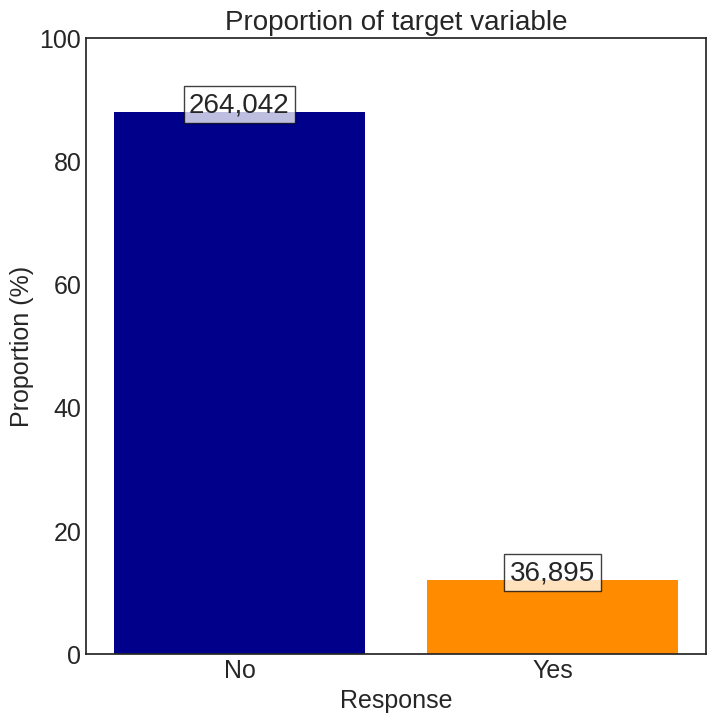

In [20]:
plt.style.use("seaborn-white")
sns.set_palette("vlag")
fig, ax = plt.subplots(figsize = (8, 8))

colors = ["darkblue", "darkorange"]
ax.bar(response_pct.index, response_pct, color = colors)

plt.ylabel("Proportion (%)", fontsize = 18)
plt.xlabel("Response", fontsize = 18)
plt.yticks(fontsize = 18)
plt.xticks(ticks = [0, 1], labels = ["No", "Yes"], fontsize = 18)
plt.title("Proportion of target variable", fontsize = 20)
plt.ylim(0, 100)

addlabels_abs(response_abs, response_pct)

plt.show()

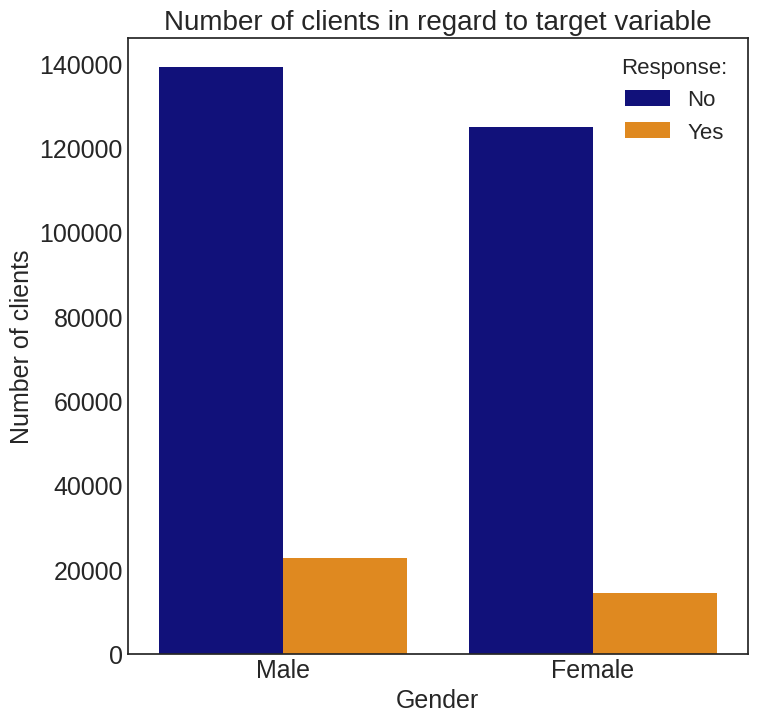

In [21]:
plt.style.use("seaborn-white")
sns.set_palette("vlag")
fig, ax = plt.subplots(figsize = (8, 8))

colours = ["#00008b", "#ff8c00"]
sns.set_palette(sns.color_palette(colours))

sns.countplot(x = data["Gender"], data = data, hue = "Response")

plt.ylabel("Number of clients", fontsize = 18)
plt.xlabel("Gender", fontsize = 18)
plt.yticks(fontsize = 18)
plt.xticks(fontsize = 18)
plt.title("Number of clients in regard to target variable", fontsize = 20)

L = plt.legend(fontsize = 16, title = "Response:", title_fontsize = 16)
L.get_texts()[0].set_text("No")
L.get_texts()[1].set_text("Yes")

plt.show()

In [22]:
data.columns

Index(['Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

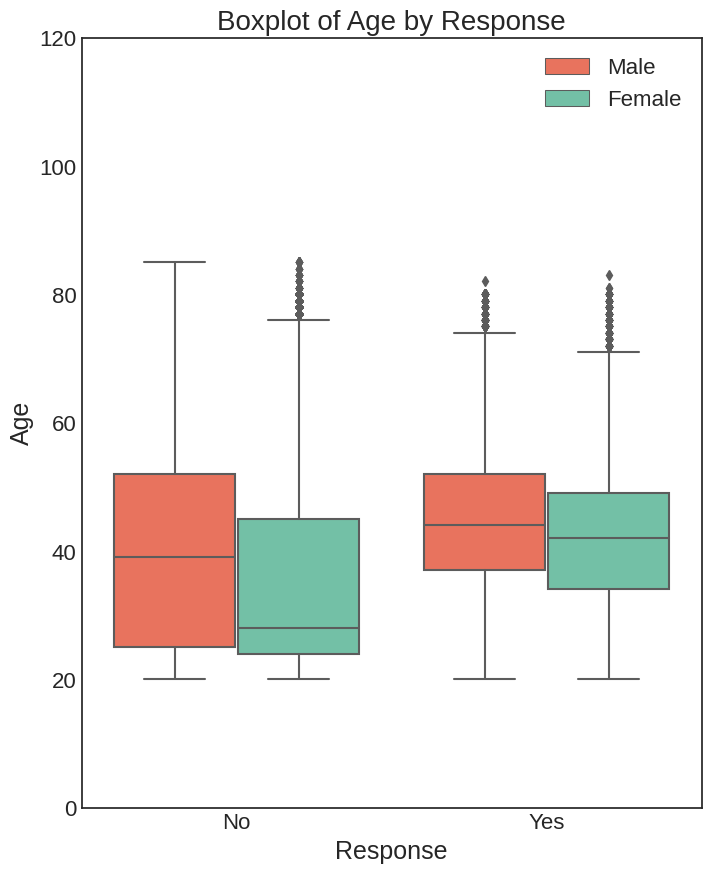

In [24]:
fig, ax = plt.subplots(figsize = (8,10))
plt.style.use("seaborn-white")
colours = ["#ff6347", "#66CDAA"]
sns.set_palette(sns.color_palette(colours))

sns.boxplot(x = "Response", y = "Age", data = data, hue = "Gender")

plt.title("Boxplot of Age by Response", fontsize = 20)
plt.xlabel("Response", fontsize = 18)
plt.xticks(ticks = [0,1], labels = ["No", "Yes"], fontsize = 16)
plt.ylabel("Age", fontsize = 18)
plt.yticks(fontsize = 16)
plt.ylim(0, 120)

plt.legend(fontsize = 16)

plt.show()

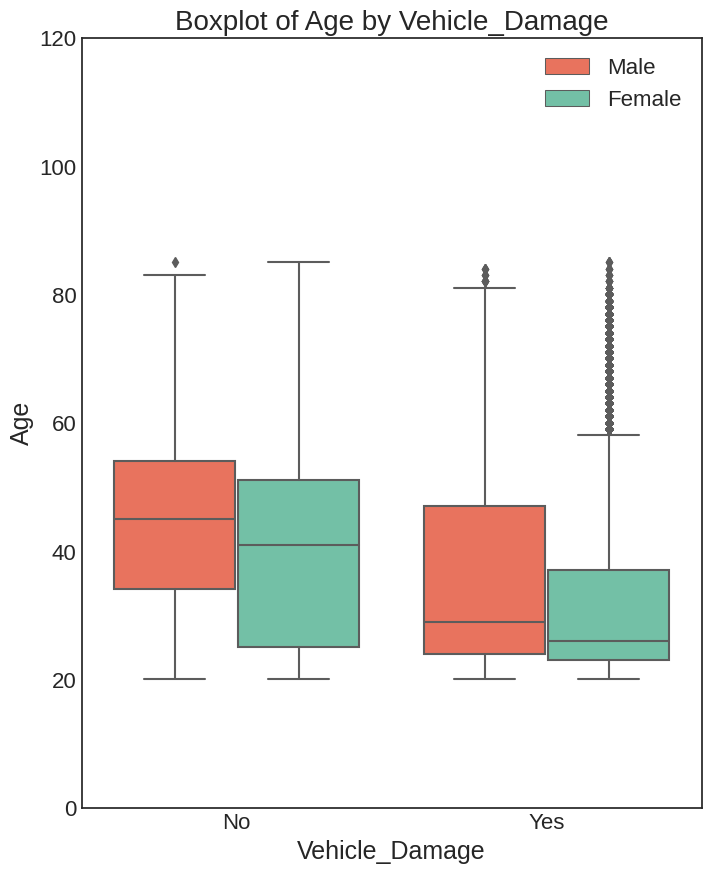

In [26]:
fig, ax = plt.subplots(figsize = (8,10))
plt.style.use("seaborn-white")
colours = ["#ff6347", "#66CDAA"]
sns.set_palette(sns.color_palette(colours))

sns.boxplot(x = "Vehicle_Damage", y = "Age", data = data, hue = "Gender")

plt.title("Boxplot of Age by Vehicle_Damage", fontsize = 20)
plt.xlabel("Vehicle_Damage", fontsize = 18)
plt.xticks(ticks = [0,1], labels = ["No", "Yes"], fontsize = 16)
plt.ylabel("Age", fontsize = 18)
plt.yticks(fontsize = 16)
plt.ylim(0, 120)

plt.legend(fontsize = 16)

plt.show()

In [ ]:
6- Barras para Vehicle_Age (x: Vehicle_age y: count, hue: target)

In [29]:
data.Vehicle_Age

0         > 2 Years
1          1-2 Year
2         > 2 Years
3          < 1 Year
4          < 1 Year
            ...    
381104     1-2 Year
381105     < 1 Year
381106     < 1 Year
381107    > 2 Years
381108     1-2 Year
Name: Vehicle_Age, Length: 300937, dtype: object

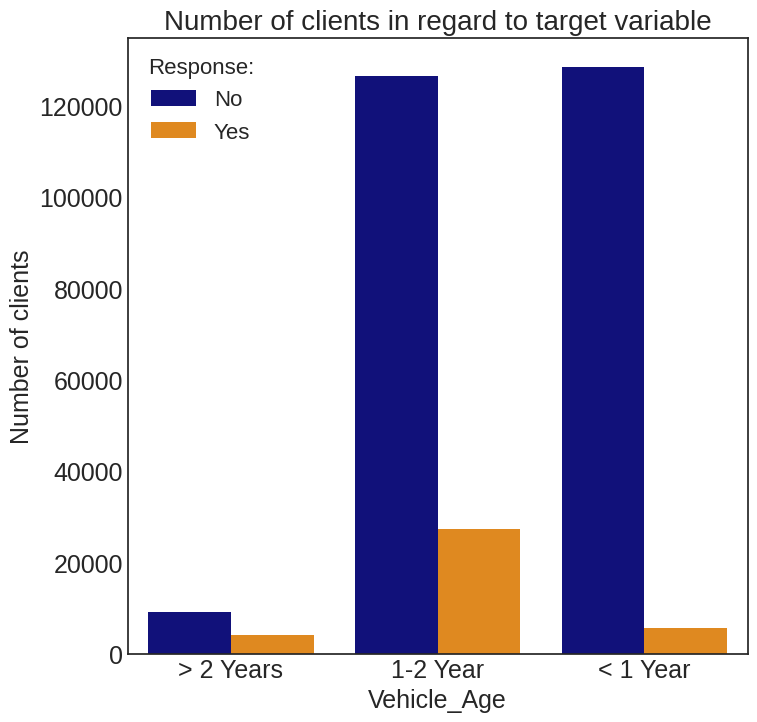

In [30]:
plt.style.use("seaborn-white")
sns.set_palette("vlag")
fig, ax = plt.subplots(figsize = (8, 8))

colours = ["#00008b", "#ff8c00"]
sns.set_palette(sns.color_palette(colours))

sns.countplot(x = data["Vehicle_Age"], data = data, hue = "Response")

plt.ylabel("Number of clients", fontsize = 18)
plt.xlabel("Vehicle_Age", fontsize = 18)
plt.yticks(fontsize = 18)
plt.xticks(fontsize = 18)
plt.title("Number of clients in regard to target variable", fontsize = 20)

L = plt.legend(fontsize = 16, title = "Response:", title_fontsize = 16)
L.get_texts()[0].set_text("No")
L.get_texts()[1].set_text("Yes")

plt.show()

In [31]:
7- Barras para Vehicle_Damage (x: Vehicle_Damage y: count, hue: target)

SyntaxError: invalid syntax (681596942.py, line 1)

In [32]:
data.Vehicle_Damage

0         Yes
1          No
2         Yes
3          No
4          No
         ... 
381104     No
381105     No
381106     No
381107    Yes
381108     No
Name: Vehicle_Damage, Length: 300937, dtype: object

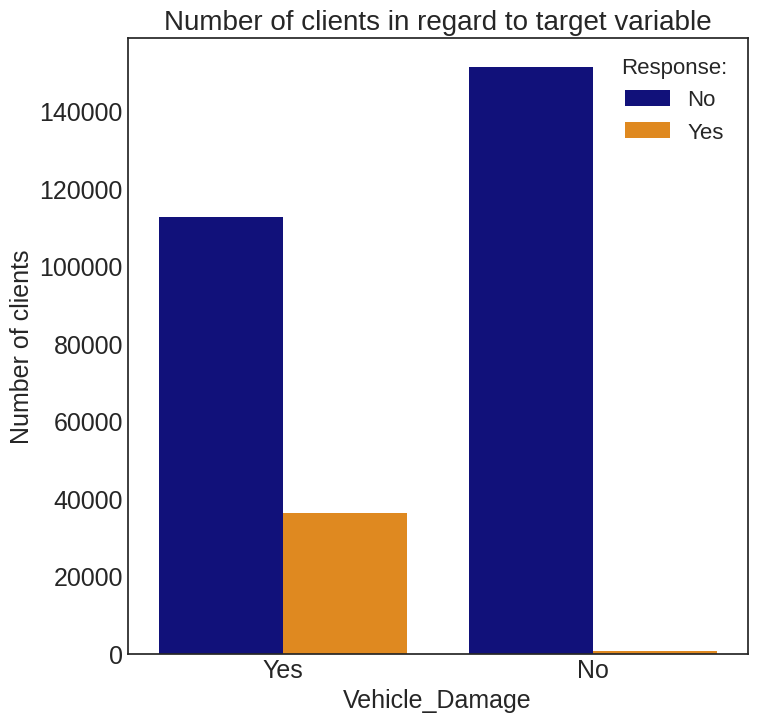

In [33]:
plt.style.use("seaborn-white")
sns.set_palette("vlag")
fig, ax = plt.subplots(figsize = (8, 8))

colours = ["#00008b", "#ff8c00"]
sns.set_palette(sns.color_palette(colours))

sns.countplot(x = data["Vehicle_Damage"], data = data, hue = "Response")

plt.ylabel("Number of clients", fontsize = 18)
plt.xlabel("Vehicle_Damage", fontsize = 18)
plt.yticks(fontsize = 18)
plt.xticks(fontsize = 18)
plt.title("Number of clients in regard to target variable", fontsize = 20)

L = plt.legend(fontsize = 16, title = "Response:", title_fontsize = 16)
L.get_texts()[0].set_text("No")
L.get_texts()[1].set_text("Yes")

plt.show()

/home/javier/Descargas/enter/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


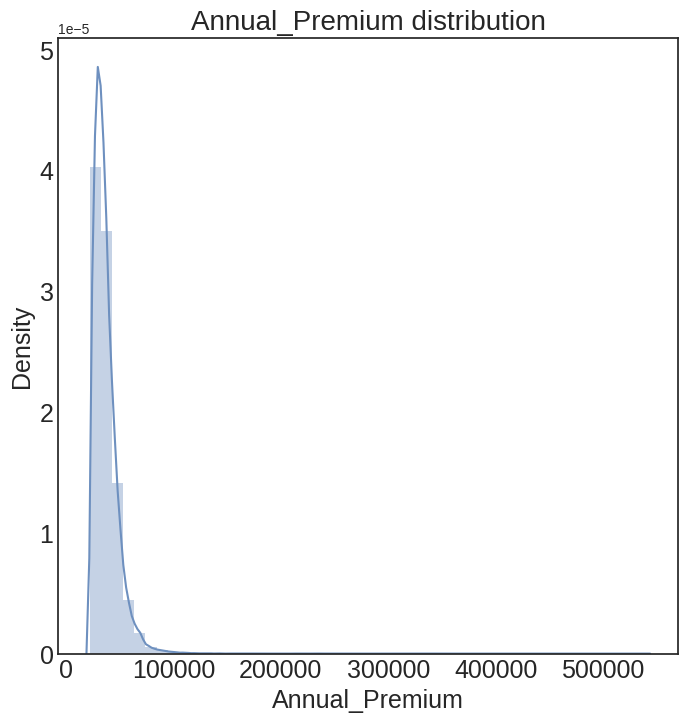

In [43]:
plt.style.use("seaborn-white")
sns.set_palette("vlag")
fig, ax = plt.subplots(figsize = (8, 8))

sns.distplot(x = data["Annual_Premium"])

plt.ylabel("Density", fontsize = 18)
plt.xlabel("Annual_Premium", fontsize = 18)
plt.yticks(fontsize = 18)
plt.xticks(fontsize = 18)
plt.title("Annual_Premium distribution", fontsize = 20)

plt.show()

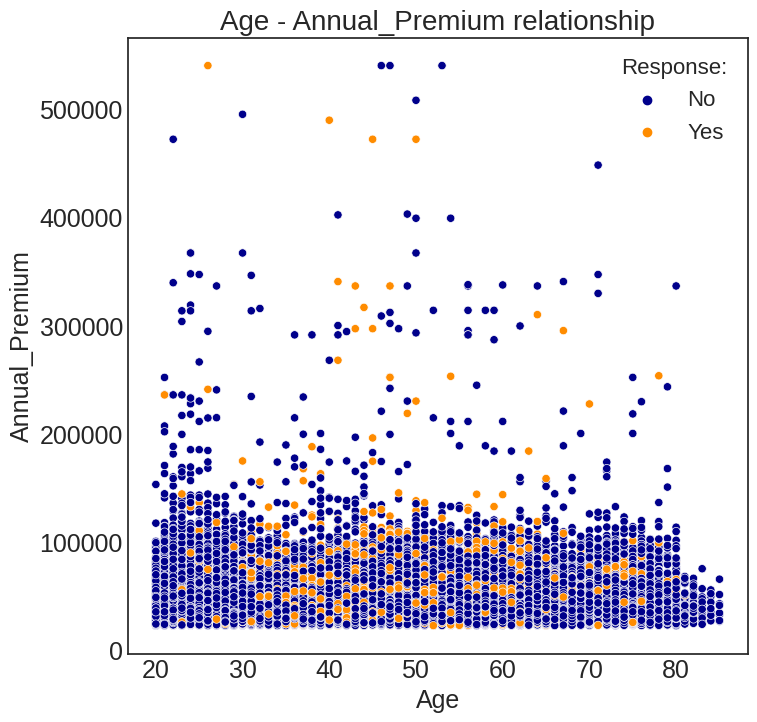

In [47]:
plt.style.use("seaborn-white")
sns.set_palette("vlag")
fig, ax = plt.subplots(figsize = (8, 8))

colours = ["#00008b", "#ff8c00"]
sns.set_palette(sns.color_palette(colours))

sns.scatterplot(x = "Age", y = "Annual_Premium", data = data, hue = "Response")

plt.ylabel("Annual_Premium", fontsize = 18)
plt.xlabel("Age", fontsize = 18)
plt.yticks(fontsize = 18)
plt.xticks(fontsize = 18)
plt.title("Age - Annual_Premium relationship", fontsize = 20)

L = plt.legend(fontsize = 16, title = "Response:", title_fontsize = 16)
L.get_texts()[0].set_text("No")
L.get_texts()[1].set_text("Yes")

plt.show()

# MIRAR!!!!

## Dummy variables

In [150]:
data = data.reset_index(drop = True)

In [151]:
data.shape

(300937, 11)

In [152]:
data.head(2)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0


Primero miro el tipo de dato de cada variable

In [153]:
data.dtypes

Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel     object
Vintage                   int64
Response                  int64
dtype: object

Genero la lista con variables numéricas y categóricas

In [154]:
numericals = ["Age", "Driving_License", "Previously_Insured", "Annual_Premium", "Vintage", "Response"]

In [155]:
categoricals = ["Gender", "Vehicle_Age", "Vehicle_Damage", "Policy_Sales_Channel"]

In [156]:
enc = OneHotEncoder(drop = "first")
X = data[categoricals]
enc.fit(X)
enc.categories_

[array(['Female', 'Male'], dtype=object),
 array(['1-2 Year', '< 1 Year', '> 2 Years'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['122.0', '152.0', '160.0', '26.0', 'other'], dtype=object)]

In [157]:
dummies = enc.transform(X).toarray()

In [158]:
dummies_df = pd.DataFrame(dummies)

In [159]:
col_names = [categoricals[i] + '_' + enc.categories_[i] for i in range(len(categoricals))] 

In [160]:
col_names_drop_first = [sublist[i] for sublist in col_names for i in range(len(sublist)) if i != 0]


In [161]:
dummies_df.columns = col_names_drop_first
dummies_df.head(2)

,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes,Policy_Sales_Channel_152.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_26.0,Policy_Sales_Channel_other
0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [162]:
data_final = pd.concat([data[numericals], dummies_df], axis = 1)

In [163]:
data_final.shape

(300937, 14)

In [164]:
data_final.head(2)

,Age,Driving_License,Previously_Insured,Annual_Premium,Vintage,Response,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes,Policy_Sales_Channel_152.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_26.0,Policy_Sales_Channel_other
0,44,1,0,40454.0,217,1,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,76,1,0,33536.0,183,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [165]:
data_final.to_csv("../documents/data_model.csv", index = False)

## train_test_split

In [126]:
X = data_final.drop('Response', axis = 1)
y = data_final.Response

In [128]:
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 123)

In [129]:
X_train.head()

,Age,Driving_License,Previously_Insured,Annual_Premium,Vintage,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes,Policy_Sales_Channel_152.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_26.0,Policy_Sales_Channel_other
69522,44,1,0,31799.0,32,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
204430,21,1,0,32375.0,111,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
178085,75,1,0,27728.0,35,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
31668,47,1,1,30654.0,204,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
127331,24,1,0,29049.0,114,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


## StandardScaler

In [132]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_val_std = scaler.transform(X_val)

In [133]:
X_train_std.to_csv('../documents/X_train_std.csv', index = False)
y_train.to_csv("../documents/y_train.csv", index = False)

AttributeError: 'numpy.ndarray' object has no attribute 'to_csv'

In [134]:
X_val_std.to_csv('../documents/X_train_std.csv', index = False)
y_val.to_csv("../documents/y_train.csv", index = False)

AttributeError: 'numpy.ndarray' object has no attribute 'to_csv'